In [2]:
from src.nhlDataClass import *

api = APIClient("https://api-web.nhle.com/v1") 
MEMORY_MANAGER = Memory_Manager()

seasons = api.get("/".join(["season"]))
print(seasons)

[19171918, 19181919, 19191920, 19201921, 19211922, 19221923, 19231924, 19241925, 19251926, 19261927, 19271928, 19281929, 19291930, 19301931, 19311932, 19321933, 19331934, 19341935, 19351936, 19361937, 19371938, 19381939, 19391940, 19401941, 19411942, 19421943, 19431944, 19441945, 19451946, 19461947, 19471948, 19481949, 19491950, 19501951, 19511952, 19521953, 19531954, 19541955, 19551956, 19561957, 19571958, 19581959, 19591960, 19601961, 19611962, 19621963, 19631964, 19641965, 19651966, 19661967, 19671968, 19681969, 19691970, 19701971, 19711972, 19721973, 19731974, 19741975, 19751976, 19761977, 19771978, 19781979, 19791980, 19801981, 19811982, 19821983, 19831984, 19841985, 19851986, 19861987, 19871988, 19881989, 19891990, 19901991, 19911992, 19921993, 19931994, 19941995, 19951996, 19961997, 19971998, 19981999, 19992000, 20002001, 20012002, 20022003, 20032004, 20052006, 20062007, 20072008, 20082009, 20092010, 20102011, 20112012, 20122013, 20132014, 20142015, 20152016, 20162017, 20172018,

In [ ]:
# Select Teams to Load Data
# Load all the teams
team_codes = [
    "ANA", "BOS", "BUF", "CAR", "CBJ", "CGY", "CHI", "COL",
    "DAL", "DET", "EDM", "FLA", "LAK", "MIN", "MTL", "NJD",
    "NSH", "NYI", "NYR", "OTT", "PHI", "PIT", "SEA", "SJS",
    "STL", "TBL", "TOR", "VAN", "VGK", "WPG", "WSH"
]

#TODO: Need to incorporate edge case Utah, which debuted in 2024/25

for code in team_codes:
    Team(code)

print("Loaded Teams")
print(Team.team_by_id)


Loaded Teams
{'MTL': <src.nhlDataClass.Team object at 0x105228ad0>, 'EDM': <src.nhlDataClass.Team object at 0x118765950>, 'BOS': <src.nhlDataClass.Team object at 0x1187665d0>, 'ANA': <src.nhlDataClass.Team object at 0x3296f09d0>, 'BUF': <src.nhlDataClass.Team object at 0x3241e7410>, 'CAR': <src.nhlDataClass.Team object at 0x32a308380>, 'CBJ': <src.nhlDataClass.Team object at 0x32a308490>, 'CGY': <src.nhlDataClass.Team object at 0x32ab71650>, 'CHI': <src.nhlDataClass.Team object at 0x32ab71750>, 'COL': <src.nhlDataClass.Team object at 0x32421db80>, 'DAL': <src.nhlDataClass.Team object at 0x32421d400>, 'DET': <src.nhlDataClass.Team object at 0x32a695c50>, 'FLA': <src.nhlDataClass.Team object at 0x32ab125b0>, 'LAK': <src.nhlDataClass.Team object at 0x32aab9550>, 'MIN': <src.nhlDataClass.Team object at 0x32aab9190>, 'NJD': <src.nhlDataClass.Team object at 0x32aa46a40>, 'NSH': <src.nhlDataClass.Team object at 0x32ab78eb0>, 'NYI': <src.nhlDataClass.Team object at 0x32ab78f50>, 'NYR': <src.nh

In [19]:
# Get a list of the seasons that the team played.
print("Seasons Played")
print(Team.team_by_id['MTL'].get_roster_season())

Seasons Played
[19171918, 19181919, 19191920, 19201921, 19211922, 19221923, 19231924, 19241925, 19251926, 19261927, 19271928, 19281929, 19291930, 19301931, 19311932, 19321933, 19331934, 19341935, 19351936, 19361937, 19371938, 19381939, 19391940, 19401941, 19411942, 19421943, 19431944, 19441945, 19451946, 19461947, 19471948, 19481949, 19491950, 19501951, 19511952, 19521953, 19531954, 19541955, 19551956, 19561957, 19571958, 19581959, 19591960, 19601961, 19611962, 19621963, 19631964, 19641965, 19651966, 19661967, 19671968, 19681969, 19691970, 19701971, 19711972, 19721973, 19731974, 19741975, 19751976, 19761977, 19771978, 19781979, 19791980, 19801981, 19811982, 19821983, 19831984, 19841985, 19851986, 19861987, 19871988, 19881989, 19891990, 19901991, 19911992, 19921993, 19931994, 19941995, 19951996, 19961997, 19971998, 19981999, 19992000, 20002001, 20012002, 20022003, 20032004, 20052006, 20062007, 20072008, 20082009, 20092010, 20102011, 20112012, 20122013, 20132014, 20142015, 20152016, 2016

In [ ]:
# Select seasons to be studied
SEASONS = ['20232024', '20242025', '20252026']

# Load Data by Season
for team in Team.team_by_id.values():
    for season in SEASONS:
        team.load_data(season)

HTTPError: 404 Client Error: Not Found for url: https://api-web.nhle.com/v1/roster/UTA/20232024

In [6]:
# Save all data in CSV

# Conditionally create 'temp' in repo only if it does not exist
from pathlib import Path

# # Create temp folder if it doesn't exist
temp_dir = Path("temp")
temp_dir.mkdir(exist_ok=True)

# Get all loaded players
print(MEMORY_MANAGER.players_df)
MEMORY_MANAGER.players_df.to_csv("temp/players.csv")
# Get all loaded events
print(MEMORY_MANAGER.events_df)
MEMORY_MANAGER.events_df.to_csv("temp/events.csv")
# Get all loaded games
print(MEMORY_MANAGER.games_df)
MEMORY_MANAGER.games_df.to_csv("temp/games.csv")


    playerId  isActive  currentTeamId currentTeamAbbrev         fullTeamName  \
0    8476981      True            8.0               MTL   Montréal Canadiens   
1    8476469      True           26.0               LAK    Los Angeles Kings   
2    8481540      True            8.0               MTL   Montréal Canadiens   
3    8481523      True            8.0               MTL   Montréal Canadiens   
4    8477989      True            4.0               PHI  Philadelphia Flyers   
..       ...       ...            ...               ...                  ...   
79   8477450      True           22.0               EDM      Edmonton Oilers   
80   8484509      True           22.0               EDM      Edmonton Oilers   
81   8476473      True           22.0               EDM      Edmonton Oilers   
82   8481056      True           22.0               EDM      Edmonton Oilers   
83   8477465      True           22.0               EDM      Edmonton Oilers   

   teamCommonName teamPlaceNameWithPrep

In [7]:
# Get Specific Player 
Player.player_by_id[8476981].json_data

{'playerId': 8476981,
 'isActive': True,
 'currentTeamId': 8,
 'currentTeamAbbrev': 'MTL',
 'fullTeamName': 'Montréal Canadiens',
 'teamCommonName': 'Canadiens',
 'teamPlaceNameWithPreposition': 'Montréal',
 'firstName': 'Josh',
 'lastName': 'Anderson',
 'badges': [],
 'teamLogo': 'https://assets.nhle.com/logos/nhl/svg/MTL_light.svg',
 'sweaterNumber': 17,
 'position': 'R',
 'headshot': 'https://assets.nhle.com/mugs/nhl/20262027/MTL/8476981.png',
 'heroImage': 'https://assets.nhle.com/mugs/actionshots/1296x729/8476981.jpg',
 'heightInInches': 75,
 'heightInCentimeters': 191,
 'weightInPounds': 226,
 'weightInKilograms': 103,
 'birthDate': '1994-05-07',
 'birthCity': 'Burlington',
 'birthStateProvince': 'Ontario',
 'birthCountry': 'CAN',
 'shootsCatches': 'R'}

In [ ]:
# Get Specific game 
Game.game_by_id[2023010018].json_data

In [ ]:
# Get Specific Player 
Event.event_by_id[14943173].json_data

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'season'}>],
       [<Axes: title={'center': 'gameType'}>,
        <Axes: title={'center': 'awayTeamId'}>],
       [<Axes: title={'center': 'homeTeamId'}>,
        <Axes: title={'center': 'winningGoalieId'}>]], dtype=object)

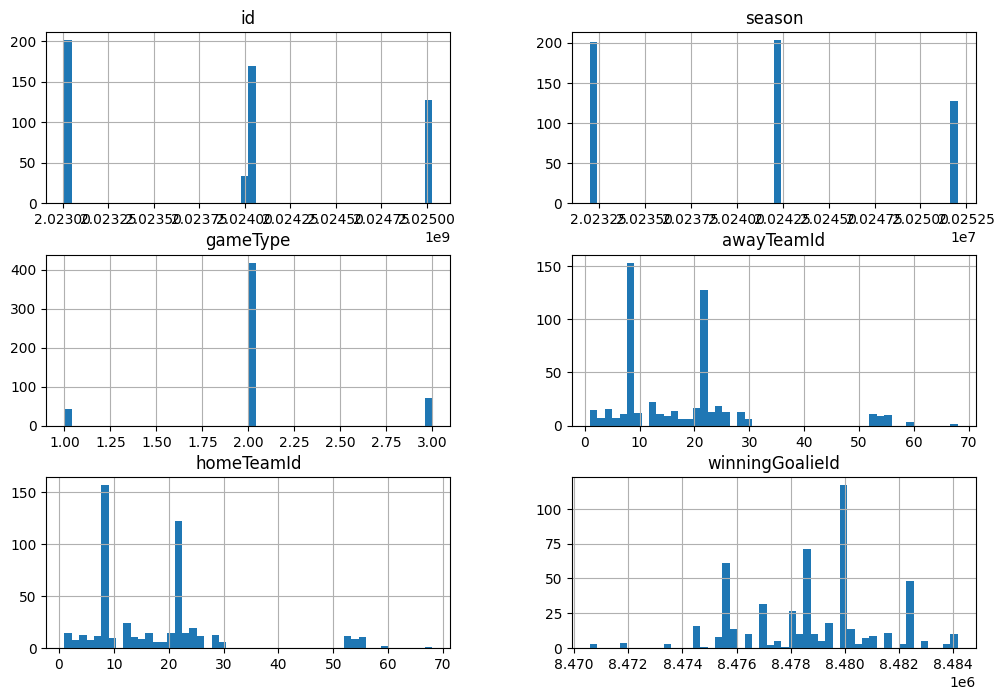

In [ ]:
# Plots for games df
games = MEMORY_MANAGER.games_df
games.hist(bins=50, figsize=(12, 8))


In [16]:
# Investigate goalie who is winning tons
games.value_counts

<bound method DataFrame.value_counts of              id    season  gameType    gameDate                 venue  \
0    2023010018  20232024         1  2023-09-25           Centre Bell   
1    2023010034  20232024         1  2023-09-27           Centre Bell   
2    2023010051  20232024         1  2023-09-29           Centre Bell   
3    2023010061  20232024         1  2023-09-30           Centre Bell   
4    2023010071  20232024         1  2023-10-02      Scotiabank Arena   
..          ...       ...       ...         ...                   ...   
526  2025020139  20252026         2  2025-10-25  Climate Pledge Arena   
527  2025020147  20252026         2  2025-10-26          Rogers Arena   
528  2025020162  20252026         2  2025-10-28          Rogers Place   
529  2025020175  20252026         2  2025-10-30          Rogers Place   
530  2025020192  20252026         2  2025-11-01          Rogers Place   

     neutralSite          startTimeUTC easternUTCOffset venueUTCOffset  \
0        

array([[<Axes: title={'center': 'playerId'}>,
        <Axes: title={'center': 'currentTeamId'}>,
        <Axes: title={'center': 'sweaterNumber'}>],
       [<Axes: title={'center': 'heightInInches'}>,
        <Axes: title={'center': 'heightInCentimeters'}>,
        <Axes: title={'center': 'weightInPounds'}>],
       [<Axes: title={'center': 'weightInKilograms'}>, <Axes: >,
        <Axes: >]], dtype=object)

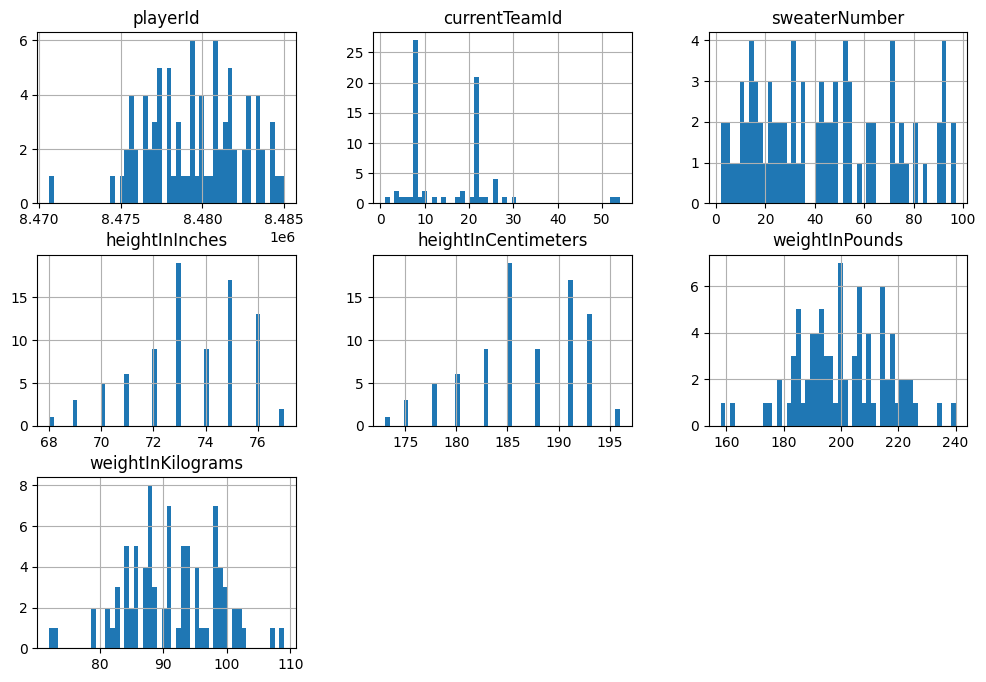

In [ ]:
# Plots for players df
players = MEMORY_MANAGER.players_df
players.hist(bins=50, figsize=(12, 8))


array([[<Axes: title={'center': 'playerId'}>,
        <Axes: title={'center': 'currentTeamId'}>,
        <Axes: title={'center': 'sweaterNumber'}>],
       [<Axes: title={'center': 'heightInInches'}>,
        <Axes: title={'center': 'heightInCentimeters'}>,
        <Axes: title={'center': 'weightInPounds'}>],
       [<Axes: title={'center': 'weightInKilograms'}>, <Axes: >,
        <Axes: >]], dtype=object)

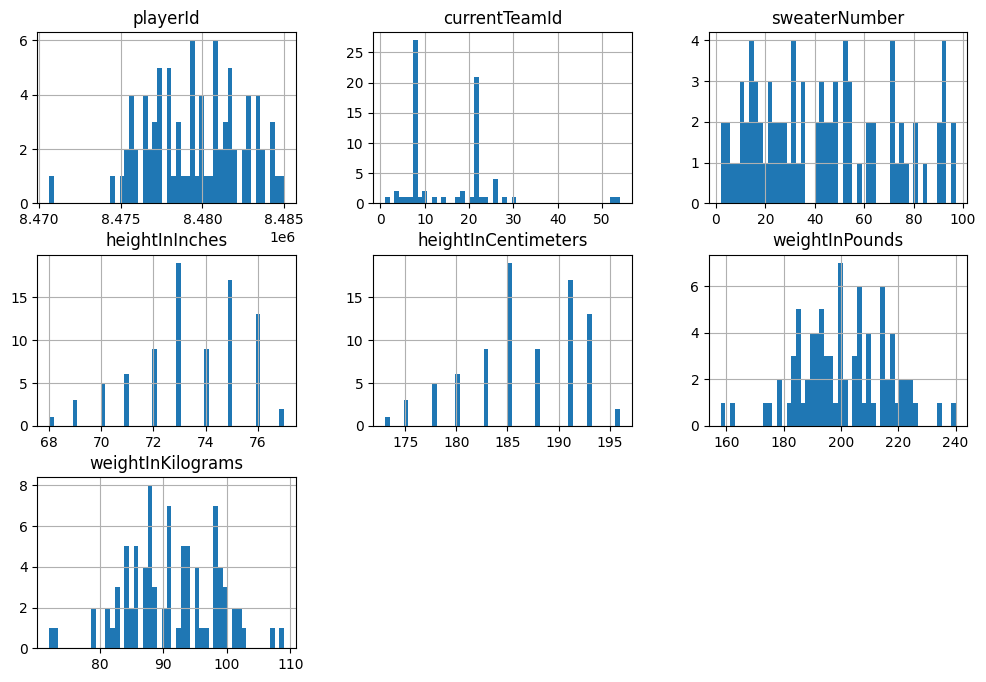

In [ ]:
# Plots for players df
players = MEMORY_MANAGER.players_df
players.hist(bins=50, figsize=(12, 8))
